# How four neurons help make one prediction

I follow a small sentiment model from its answer to the neurons behind it. I then turn off one neuron to check its role, and look for an example that limits my explanation.

The model knows six words: `good`, `great`, `happy`, `bad`, `awful`, and `sad`. The correct label follows the majority of positive or negative words. Word order is ignored.

**Set up the model**

The team trained on 28 word combinations and held out 4 for validation. I reproduce that training with the same random seed because no saved weights were supplied. The sample results match the team's saved notebook to four decimal places. This is a toy word task, not a test of real sentences.

In [1]:
from itertools import combinations
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

random.seed(42)
torch.manual_seed(42)

import matplotlib.pyplot as plt


In [2]:
from pathlib import Path
figure_dir = Path("investigation")
figure_dir.mkdir(exist_ok=True)
POSITIVE_COLOR = "#4c78a8"
NEGATIVE_COLOR = "#f58518"
NEUTRAL_COLOR = "#b8b8b8"

def save_step_figure(fig, filename):
    fig.savefig(figure_dir / filename, dpi=160, bbox_inches="tight")
    plt.show()


In [3]:
words = ["good", "great", "happy", "bad", "awful", "sad"]
class_names = ["negative", "positive"]
word_to_index = {word: index for index, word in enumerate(words)}

def encode_texts(texts):
    features = torch.zeros((len(texts), len(words)))
    for row, text in enumerate(texts):
        for word in text.split():
            features[row, word_to_index[word]] += 1
    return features

train_data, val_data = [], []
for length in [1, 3, 5]:
    groups = {0: [], 1: []}
    for indices in combinations(range(len(words)), length):
        positive_count = sum(index < 3 for index in indices)
        label = int(positive_count > length / 2)
        text = " ".join(words[index] for index in indices)
        groups[label].append((text, label))
    for examples in groups.values():
        random.shuffle(examples)
        if length == 1:
            train_data.extend(examples)
        else:
            val_data.append(examples[0])
            train_data.extend(examples[1:])

random.shuffle(train_data)
train_texts, train_labels = zip(*train_data)
val_texts, val_labels = zip(*val_data)
X_train = encode_texts(train_texts)
X_val = encode_texts(val_texts)
y_train = torch.tensor(train_labels, dtype=torch.long)
y_val = torch.tensor(val_labels, dtype=torch.long)

print(f"Training examples: {len(train_data)}, validation examples: {len(val_data)}")
print("Input columns:", words)


Training examples: 28, validation examples: 4
Input columns: ['good', 'great', 'happy', 'bad', 'awful', 'sad']


In [4]:
class SentimentMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(6, 4)
        self.fc2 = nn.Linear(4, 2)

    def forward(self, x):
        hidden = F.relu(self.fc1(x))
        return self.fc2(hidden), hidden

model = SentimentMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
criterion = nn.CrossEntropyLoss()

losses = []
for epoch in range(100):
    logits, _ = model(X_train)
    loss = criterion(logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(model)
print(f"Final training loss: {losses[-1]:.4f}")

model.eval()
with torch.no_grad():
    val_logits, _ = model(X_val)
    val_predictions = val_logits.argmax(dim=1)
    val_accuracy = (val_predictions == y_val).float().mean().item()
print(f"Validation accuracy: {val_accuracy:.0%} ({len(val_data)} held-out combinations)")


SentimentMLP(
  (fc1): Linear(in_features=6, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=2, bias=True)
)
Final training loss: 0.0001
Validation accuracy: 100% (4 held-out combinations)


## Step 1. Start with one answer

For `good bad happy`, two words are positive and one is negative. The expected answer is positive.

The model converts the words into six numbers indicating which words are present. Four hidden neurons then produce responses, called **activations**. The model combines these responses into a negative score and a positive score; the larger score wins.

The left chart shows the four responses. The right chart shows the final scores. A larger activation means a stronger response, but does not by itself mean support for positive.

The input is "good bad happy".
The model gives negative a score of -4.39 and positive a score of 5.21.
The larger score belongs to positive, so that is the prediction.
The hidden bars show response strength. Their height alone does not tell us which answer they support.

Overall: For this input, neurons 0, 1, and 2 are active. The model gives positive a higher score, so it predicts positive.


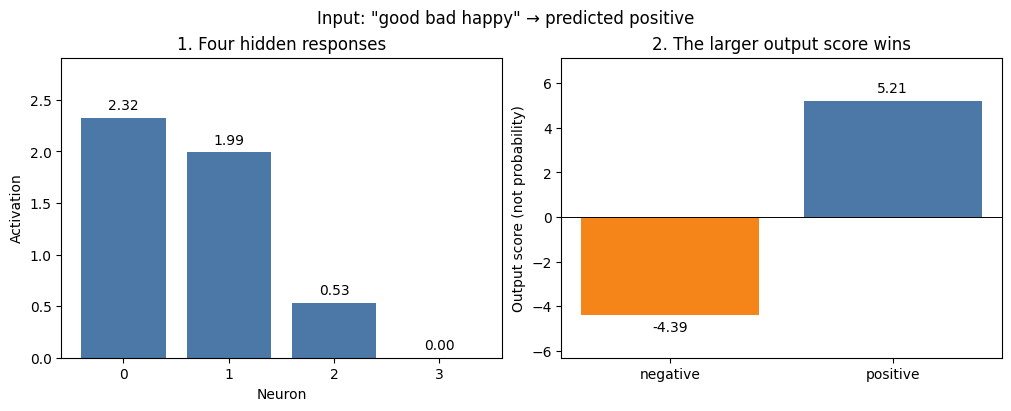

In [5]:
sample_text = "good bad happy"

# Follow one input from hidden responses to the final answer.
with torch.no_grad():
    sample_scores, sample_hidden = model(encode_texts([sample_text]))
sample_answer = class_names[sample_scores.argmax(1).item()]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
response_bars = axes[0].bar(range(4), sample_hidden[0].tolist(), color=POSITIVE_COLOR)
axes[0].bar_label(response_bars, fmt="%.2f", padding=4)
axes[0].set(title="1. Four hidden responses", xlabel="Neuron", ylabel="Activation", xticks=range(4))
axes[0].set_ylim(0, max(sample_hidden[0].max().item() * 1.25, 1))
score_bars = axes[1].bar(class_names, sample_scores[0].tolist(), color=[NEGATIVE_COLOR, POSITIVE_COLOR])
axes[1].bar_label(score_bars, fmt="%.2f", padding=4)
axes[1].axhline(0, color="black", linewidth=.7)
axes[1].margins(y=.2)
axes[1].set(title="2. The larger output score wins", ylabel="Output score (not probability)")
fig.suptitle(f'Input: "{sample_text}" → predicted {sample_answer}')
save_step_figure(fig, "step3_one_prediction.png")
print(f'The input is "{sample_text}".')
print(f'The model gives negative a score of {sample_scores[0, 0]:.2f} and positive a score of {sample_scores[0, 1]:.2f}.')
print(f'The larger score belongs to {sample_answer}, so that is the prediction.')
print('The hidden bars show response strength. Their height alone does not tell us which answer they support.')
active_neurons = [str(j) for j in range(4) if sample_hidden[0, j].item() > 0]
if len(active_neurons) > 1:
    active_description = ', '.join(active_neurons[:-1]) + ', and ' + active_neurons[-1] if len(active_neurons) > 2 else ' and '.join(active_neurons)
    response_description = f'neurons {active_description} are active'
elif active_neurons:
    response_description = f'neuron {active_neurons[0]} is active'
else:
    response_description = 'all four neurons are inactive'
print()
print(f'Overall: For this input, {response_description}. '
      f'The model gives {sample_answer} a higher score, so it predicts {sample_answer}.')


The model gets this example right. But one example does not tell us what each neuron usually responds to. I next compare positive and negative inputs.

## Step 2. Look for a pattern across inputs

I check all 32 allowed combinations: 16 positive and 16 negative. These include the 28 training examples and 4 validation examples; they are not 32 new test examples.

For each neuron, I compare its average response to the two groups. Taller bars mean stronger average responses.

Neuron 0 responds more strongly to positive inputs on average: 0.11 for negative and 2.35 for positive.
Neuron 1 responds more strongly to positive inputs on average: 0.20 for negative and 2.44 for positive.
Neuron 2 responds more strongly to negative inputs on average: 2.98 for negative and 0.66 for positive.
Neuron 3 stays at zero on all 32 inputs.
These are group averages. They do not mean that every input follows the same pattern.

Overall: Across all 32 inputs, neurons 0 and 1 respond more strongly to positive combinations on average. Neuron 2 responds more strongly to negative combinations, while neuron 3 stays inactive.


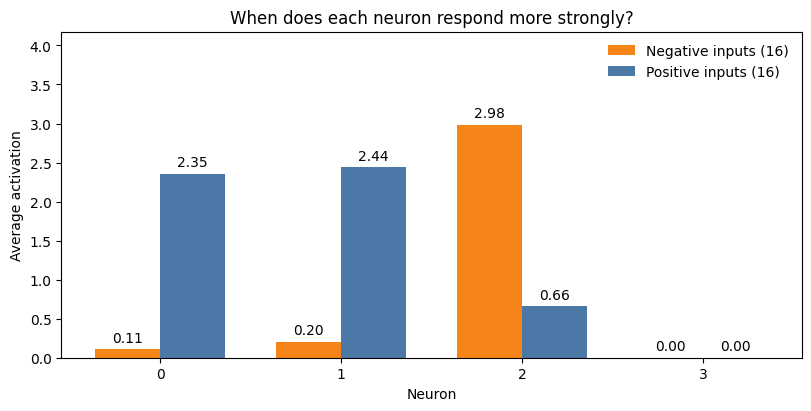

In [6]:
import csv
from pathlib import Path
output_dir = Path("investigation")
output_dir.mkdir(exist_ok=True)
all_texts = [" ".join(words[i] for i in ids)
             for length in [1, 3, 5]
             for ids in combinations(range(6), length)]
X_all = encode_texts(all_texts)
balance = X_all[:, :3].sum(1) - X_all[:, 3:].sum(1)
y_all = (balance > 0).long()
with torch.no_grad():
    scores, H = model(X_all)
    W = model.fc1.weight.detach()
    b = model.fc1.bias.detach()
    margin_weights = (model.fc2.weight[1] - model.fc2.weight[0]).detach()
    margin_bias = (model.fc2.bias[1] - model.fc2.bias[0]).detach()
    margin = scores[:, 1] - scores[:, 0]
    contribution = H * margin_weights
assert torch.allclose(margin, contribution.sum(1) + margin_bias, atol=1e-5)


# A simple class-average view complements the detailed all-input plots.
negative_means = H[y_all == 0].mean(0)
positive_means = H[y_all == 1].mean(0)
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
for label, means, offset, color in [
    ("Negative inputs (16)", negative_means, -.18, NEGATIVE_COLOR),
    ("Positive inputs (16)", positive_means, .18, POSITIVE_COLOR),
]:
    bars = ax.bar([j + offset for j in range(4)], means.tolist(), width=.36, label=label, color=color)
    ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set(title="When does each neuron respond more strongly?", xlabel="Neuron", ylabel="Average activation", xticks=range(4))
ax.set_ylim(0, max(negative_means.max(), positive_means.max()).item() * 1.4)
ax.legend(frameon=False)
save_step_figure(fig, "step4_average_responses.png")
for j in range(4):
    active_count = (H[:, j] > 0).sum().item()
    if active_count == 0:
        print(f'Neuron {j} stays at zero on all {len(all_texts)} inputs.')
    else:
        stronger = 'negative' if negative_means[j] > positive_means[j] else 'positive'
        print(f'Neuron {j} responds more strongly to {stronger} inputs on average: '
              f'{negative_means[j]:.2f} for negative and {positive_means[j]:.2f} for positive.')
print('These are group averages. They do not mean that every input follows the same pattern.')
if (positive_means[:2] > negative_means[:2]).all() and negative_means[2] > positive_means[2] and (H[:, 3] == 0).all():
    print()
    print(f'Overall: Across all {len(all_texts)} inputs, neurons 0 and 1 respond more strongly '
          'to positive combinations on average. Neuron 2 responds more strongly to negative '
          'combinations, while neuron 3 stays inactive.')


Neuron 2 stands out because its average response is stronger for negative inputs. This gives me a question to test: **does neuron 2 push the model toward a negative answer?**

## Step 3. See which way the neurons push

I return to `good bad happy`. This chart shows how much each neuron contributes to **positive score minus negative score**. Bars pointing right support positive; bars pointing left support negative.

Each contribution is the activation multiplied by its output weight difference. The fixed offset is an extra constant the output layer adds. Adding every bar gives the final score difference.

Neuron 0 pushes toward positive by 6.55 score units.
Neuron 1 pushes toward positive by 5.67 score units.
Neuron 2 pushes toward negative by 1.70 score units.
Neuron 3 adds zero for this input.
Adding these contributions and the fixed offset gives +9.60.
This matches positive score minus negative score: +9.60.
A neuron can support the negative answer even when the final answer is positive.


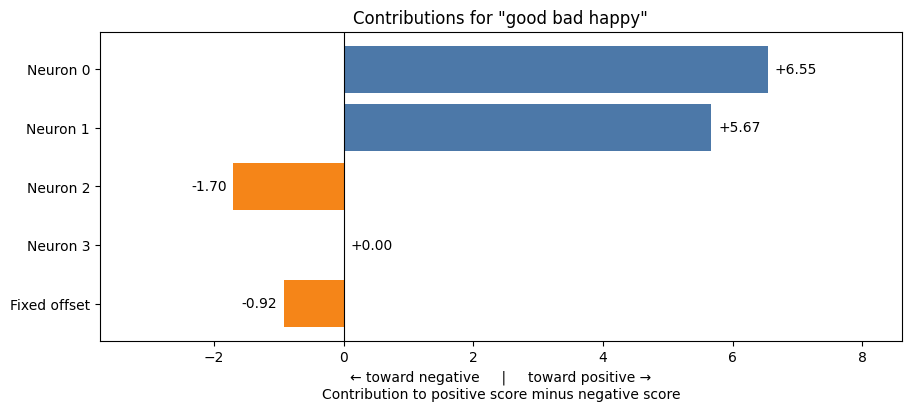

In [7]:
# Actual contributions for one input, including the output-layer offset.
sample_parts = sample_hidden[0] * margin_weights
values = sample_parts.tolist() + [margin_bias.item()]
labels = [f"Neuron {j}" for j in range(4)] + ["Fixed offset"]
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
colors = [POSITIVE_COLOR if v > 0 else NEGATIVE_COLOR if v < 0 else NEUTRAL_COLOR for v in values]
bars = ax.barh(labels, values, color=colors)
ax.bar_label(bars, labels=[f"{v:+.2f}" for v in values], padding=5)
ax.axvline(0, color="black", linewidth=.8)
ax.invert_yaxis()
ax.margins(x=.25)
ax.set(title=f'Contributions for "{sample_text}"', xlabel="← toward negative     |     toward positive →\nContribution to positive score minus negative score")
save_step_figure(fig, "step5_output_contributions.png")
for j, value in enumerate(sample_parts.tolist()):
    direction = 'positive' if value > 0 else 'negative'
    if value == 0:
        print(f'Neuron {j} adds zero for this input.')
    else:
        print(f'Neuron {j} pushes toward {direction} by {abs(value):.2f} score units.')
total = sum(values)
print(f'Adding these contributions and the fixed offset gives {total:+.2f}.')
print(f'This matches positive score minus negative score: {(sample_scores[0, 1] - sample_scores[0, 0]).item():+.2f}.')
assert abs(total - (sample_scores[0, 1] - sample_scores[0, 0]).item()) < 1e-5
print('A neuron can support the negative answer even when the final answer is positive.')


For this example, neurons 0 and 1 push toward positive, while neuron 2 pushes toward negative. The positive contributions are larger overall, so the final answer is still positive.

This explains a contribution mathematically. I next remove it and see whether the answer changes.

## Step 4. Turn off a neuron and check what changes

I set one neuron's activation to zero, keep everything else unchanged, and repeat this for all 32 inputs. This is called **ablation**. I do not retrain the model.

The left chart counts changed answers. The right chart measures changes in the score difference. Looking at both matters: scores can move even if the final answer stays the same.

Turning off neuron 0 changes 0 of 32 labels. The average size of the score change is 3.47.
Turning off neuron 1 changes 0 of 32 labels. The average size of the score change is 3.76.
Turning off neuron 2 changes 5 of 32 labels. The average size of the score change is 5.82.
Turning off neuron 3 changes 0 of 32 labels. The average size of the score change is 0.00.
No label change does not mean no contribution: a score can move without crossing zero.
Example (training): "great awful sad" changes from negative to positive when neuron 2 is turned off.


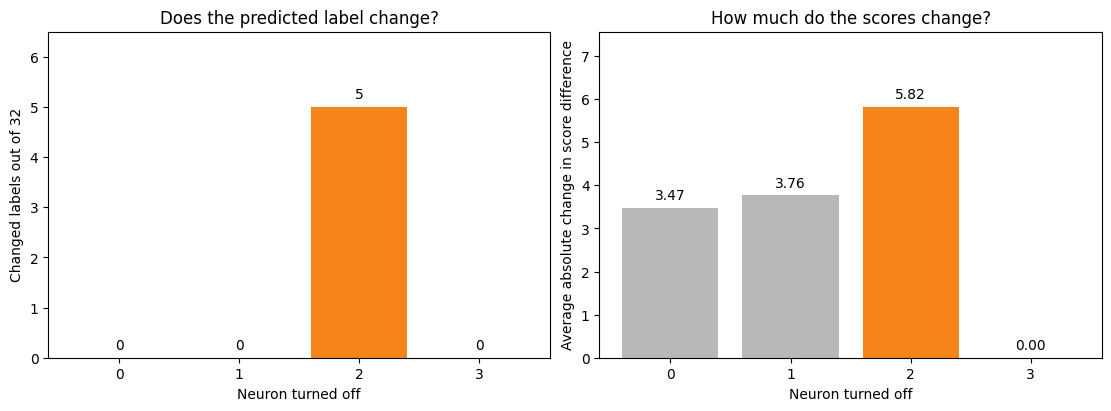

In [8]:
ablated_margins = []
with torch.no_grad():
    for j in range(4):
        modified = H.clone()
        modified[:, j] = 0
        new_scores = model.fc2(modified)
        new_margin = new_scores[:, 1] - new_scores[:, 0]
        ablated_margins.append(new_margin)
        # Removing a unit subtracts its contribution in this linear output layer.
        assert torch.allclose(new_margin - margin, -contribution[:, j], atol=1e-5)

# Show label changes separately from changes in the output scores.
baseline_labels = scores.argmax(1)
changed_counts = [int(((m > 0).long() != baseline_labels).sum()) for m in ablated_margins]
mean_changes = [(m - margin).abs().mean().item() for m in ablated_margins]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, values, title, ylabel in [
    (axes[0], changed_counts, "Does the predicted label change?", "Changed labels out of 32"),
    (axes[1], mean_changes, "How much do the scores change?", "Average absolute change in score difference"),
]:
    bars = ax.bar(range(4), values, color=[NEUTRAL_COLOR, NEUTRAL_COLOR, NEGATIVE_COLOR, NEUTRAL_COLOR])
    ax.bar_label(bars, labels=[f"{v:g}" if ax is axes[0] else f"{v:.2f}" for v in values], padding=4)
    ax.set(title=title, ylabel=ylabel, xlabel="Neuron turned off", xticks=range(4))
    ax.set_ylim(0, max(max(values) * 1.3, 1))
save_step_figure(fig, "step6_turning_neurons_off.png")
for j in range(4):
    print(f'Turning off neuron {j} changes {changed_counts[j]} of {len(all_texts)} labels. '
          f'The average size of the score change is {mean_changes[j]:.2f}.')
print('No label change does not mean no contribution: a score can move without crossing zero.')
changed_examples = (baseline_labels != (ablated_margins[2] > 0).long()).nonzero().flatten()
if len(changed_examples):
    k = changed_examples[0].item()
    split = 'validation' if all_texts[k] in val_texts else 'training'
    print(f'Example ({split}): "{all_texts[k]}" changes from '
          f'{class_names[baseline_labels[k].item()]} to {class_names[int(ablated_margins[2][k] > 0)]} '
          f'when neuron 2 is turned off.')


Turning off neuron 2 changes 5 of the 32 answers, including 3 training examples and 2 validation examples. This supports a role in some decisions. Removing neuron 0 or 1 individually changes scores but no answers on this set.

I now check whether my explanation is too broad.

## Step 5. Look for a counterexample

Could I say “neuron 2 only responds to negative inputs”? I check a positive input, `good`, and compare it with a negative input.

Even a small response above zero on a positive input would challenge the word “only”.

Statement to test: "Neuron 2 activates only for negative inputs."
Counterexample: "good" is positive, but neuron 2 has activation 0.183.
In fact, it activates on 15 of 16 positive inputs.
So we reject the word "only". A stronger average response to negative inputs still fits the evidence.


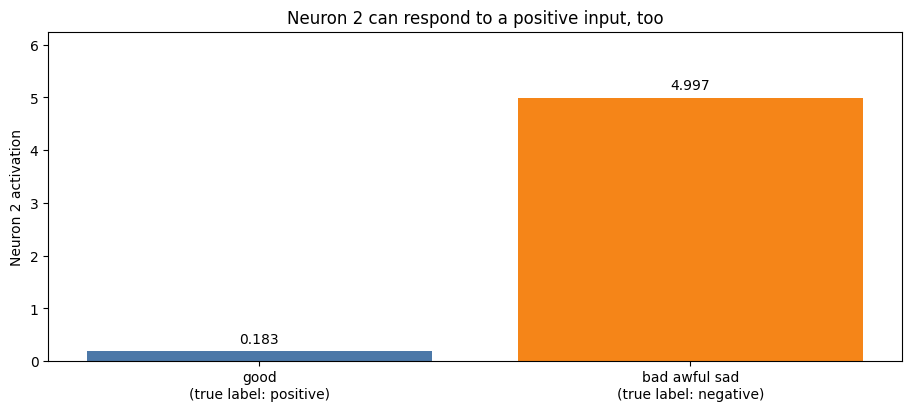

In [9]:
# Test the overly strong statement with a concrete positive example.
counter_candidates = ((y_all == 1) & (H[:, 2] > 0)).nonzero().flatten()
counter_index = min(counter_candidates.tolist(), key=lambda k: len(all_texts[k].split()))
negative_index = H[:, 2].argmax().item()
chosen = [counter_index, negative_index]
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
example_labels = [f'{all_texts[k]}\n(true label: {class_names[y_all[k].item()]})' for k in chosen]
bars = ax.bar(example_labels, [H[k, 2].item() for k in chosen], color=[POSITIVE_COLOR, NEGATIVE_COLOR])
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set(title="Neuron 2 can respond to a positive input, too", ylabel="Neuron 2 activation")
ax.set_ylim(0, H[:, 2].max().item() * 1.25)
save_step_figure(fig, "step7_counterexample.png")
print('Statement to test: "Neuron 2 activates only for negative inputs."')
print(f'Counterexample: "{all_texts[counter_index]}" is positive, but neuron 2 has activation {H[counter_index, 2]:.3f}.')
print(f'In fact, it activates on {len(counter_candidates)} of {int((y_all == 1).sum())} positive inputs.')
print('So we reject the word "only". A stronger average response to negative inputs still fits the evidence.')


The positive example has a response above zero. So I should describe neuron 2 as contributing toward negative, rather than as a detector that only turns on for negative inputs.

## Step 6. Put the evidence together

The story now has three pieces: neuron 2 responds more strongly to negative inputs on average; its contribution pushes toward negative; and removing it changes some answers. The counterexample keeps the claim specific.

**What we found**

Neuron 2 responds more strongly to negative combinations on average. Whenever it activates, it pushes the output toward a negative answer.

**Why we think so**

- Its average activation is **2.98 for negative inputs**, compared with **0.66 for positive inputs**.
- Each unit of activation lowers the positive-minus-negative score difference by **3.20**.
- Turning it off changes **5 of 32 answers**, reducing accuracy from **100% to 84.4%** on these combinations.

**What we cannot claim**

Neuron 2 is not an exclusive negative detector: it also activates on **15 of 16 positive inputs**. We inspected 28 training examples and only 4 held-out examples from one seeded model. This six-word task ignores word order and does not show understanding of real sentences.

**What I would check next**

I would turn off neurons 0 and 1 together to see whether their contributions compensate for one another. I would also repeat training with different random seeds to check whether similar roles appear again.

**Save the evidence**

The figures, per-input results, and reproduced model weights are saved in `investigation` so these findings can be checked again.

In [10]:
with (output_dir / "per_input_evidence.csv").open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["text", "split", "label", "balance", "baseline_margin"] +
                    [f"activation_{j}" for j in range(4)] +
                    [f"margin_after_ablating_{j}" for j in range(4)])
    for k, text in enumerate(all_texts):
        writer.writerow([text, "validation" if text in val_texts else "train", y_all[k].item(),
                         balance[k].item(), margin[k].item()] + H[k].tolist() +
                        [m[k].item() for m in ablated_margins])


torch.save(model.state_dict(), output_dir / "reproduced_model_state.pt")
